In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

import warnings
warnings.filterwarnings("ignore")

import scpositioner as sp
from scpositioner.tl import LowResMapper

In [2]:
# demo data can be downloaded via https://drive.google.com/drive/folders/1UOBifg53QwayzZwXbGYCJSvmDc58RofD?usp=sharing
sc_adata = sc.read('sc_kidney.h5ad')
st_adata = sc.read('st_kidney.h5ad')

In [3]:
sc_adata

AnnData object with n_obs × n_vars = 6540 × 14647
    obs: 'nGene', 'nUMI', 'orig.ident', 'replicate', 'percent.mito', 'sex', 'res.1', 'Lineages', 'Ontology_ID', 'Cell_type', 'tsne1', 'tsne2', 'Cell', 'n_genes'
    var: 'n_cells'

In [4]:
st_adata

AnnData object with n_obs × n_vars = 3124 × 14647
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'

In [5]:
# Optional: For spot-level spatial reference, you may input your own deconvolution(cell-type composition in each spot) results or run cell2location first.
# We also provide a cell2location tutorial to help users deconvolute in advance.
# If the deconv_res is not provided, scPositioner will run cell2location automatically.
deconv_res = pd.read_csv('C2L_res_kidney.csv', index_col=0)

In [6]:
# the deconvolution result should be input as pd.DataFrame in the format of spot x celltype
deconv_res

,Distal tubule,Intercalated cells,Principal cells,Proximal tubule,Renal corpuscle,Thin limb of Loop of Henle
AAACAAGTATCTCCCA-1,0.639572,0.009867,0.004702,0.254937,0.052408,0.038514
AAACAATCTACTAGCA-1,0.199913,0.435638,0.077317,0.244214,0.042632,0.000286
AAACAGAGCGACTCCT-1,0.081853,0.027252,0.000500,0.819810,0.070521,0.000064
AAACATTTCCCGGATT-1,0.799549,0.007770,0.024452,0.007573,0.098908,0.061749
AAACCCGAACGAAATC-1,0.237077,0.016646,0.002901,0.712419,0.017622,0.013335
...,...,...,...,...,...,...
TTGTTCAGTGTGCTAC-1,0.494255,0.023726,0.039207,0.281260,0.091377,0.070174
TTGTTGTGTGTCAAGA-1,0.607432,0.021862,0.034429,0.201996,0.073981,0.060299
TTGTTTCACATCCAGG-1,0.002112,0.002676,0.414966,0.001805,0.095519,0.482922
TTGTTTCCATACAACT-1,0.070774,0.014427,0.005052,0.907268,0.000808,0.001671


In [7]:
mapper = LowResMapper(
            S = sc_adata,
            R = st_adata,
            deconv_res = deconv_res,
            celltype_key = 'Cell_type',
            estimate_cell_number_list = None,
            mean_cell_numbers = 5,
            normalize = True,
            numItermax = 1e6,
            seed = 0)

# If deconv_res is not provided, scPositioner will run cell2location automatically.
# For this, ensure cell2location is installed previously.
# mapper = LowResMapper(
#            S = sc_adata,
#            R = st_adata,
#            deconv_res = None, #deconv_res is not provided,
#            celltype_key = 'Cell_type',
#            estimate_cell_number_list = None,
#            mean_cell_numbers = 5,
#            normalize = True,
#            numItermax = 1e6,
#            seed = 0)

In [8]:
adata_new = mapper.run()

[2026-08-09 21:13:40] Checking single cell AnnData: 6540 cells * 14647 features, 6 cell types.
[2026-08-09 21:13:40] Checking spatial reference AnnData: 3124 spots * 14647 features; 'estimate_cell_number_list' is provided: False.
[2026-08-09 21:13:40] Filtering features and cells...
[2026-08-09 21:13:42] Estimating cell numbers per spot based on normalized data...
[2026-08-09 21:13:42] Adjusting cell aboundance in single cell AnnData...
[2026-08-09 21:13:43] 14647 common features are used for mapping...
[2026-08-09 21:13:46] Calculating cost matrix (cosine similarity)...
[2026-08-09 21:13:48] Running optimal transport...


RESULT MIGHT BE INACURATE
Max number of iteration reached, currently 1000000. Sometimes iterations go on in cycle even though the solution has been reached, to check if it's the case here have a look at the minimal reduced cost. If it is very close to machine precision, you might actually have the correct solution, if not try setting the maximum number of iterations a bit higher


[2026-08-09 21:14:05] Assigning cells...
[2026-08-09 21:14:06] Creating new AnnData object...
[2026-08-09 21:14:09] Done!


In [9]:
adata_new.write('kidney_mapped.h5ad')

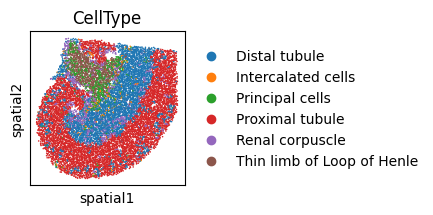

In [10]:
plt.rcParams["figure.figsize"] = (2, 2)
sc.pl.embedding(adata_new, basis='spatial', color='CellType', s=5)